In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ________Data Cleaning & Preprocessing_______

In [2]:
#Load Dataset
df=pd.read_csv("stores_sales_forecasting.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,5041.643564,55726.556341,349.834887,3.785007,0.173923,8.699327
std,2885.740258,32261.888225,503.179145,2.251620,0.181547,136.049246
min,1.000000,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,90032.000000,435.168000,5.000000,0.300000,33.726600
max,9991.000000,99301.000000,4416.174000,14.000000,0.700000,1013.127000


In [9]:
# Checking null values 
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [15]:
# Drop Duplicate Data 
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [20]:
#Checking Unique Values in Each Column
df.nunique()

Row ID           2121
Order ID         1764
Order Date        889
Ship Date         960
Ship Mode           4
Customer ID       707
Customer Name     707
Segment             3
Country             1
City              371
State              48
Postal Code       454
Region              4
Product ID        375
Category            1
Sub-Category        4
Product Name      380
Sales            1636
Quantity           14
Discount           11
Profit           1777
dtype: int64

In [21]:
# Drop columns that have only one unique value
df.drop(columns=df.nunique()[df.nunique() == 1].index, inplace=True)
# Display the updated DataFrame
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,Los Angeles,California,90032,West,FUR-FU-10001487,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,Los Angeles,California,90032,West,FUR-TA-10001539,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [ ]:
# Dropping Unnecesary Columns
columns_to_drop=['Row ID','Order ID','Customer ID','Ship Date','Order Date','Product ID','Postal Code','Customer Name']
df.drop(columns=columns_to_drop, inplace=True)


In [24]:
df.head()

,Ship Mode,Segment,City,State,Region,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,Henderson,Kentucky,South,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,Second Class,Consumer,Henderson,Kentucky,South,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,Standard Class,Consumer,Fort Lauderdale,Florida,South,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,Standard Class,Consumer,Los Angeles,California,West,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,Standard Class,Consumer,Los Angeles,California,West,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


# ____________Exploratory Data Analysis (EDA)_____________

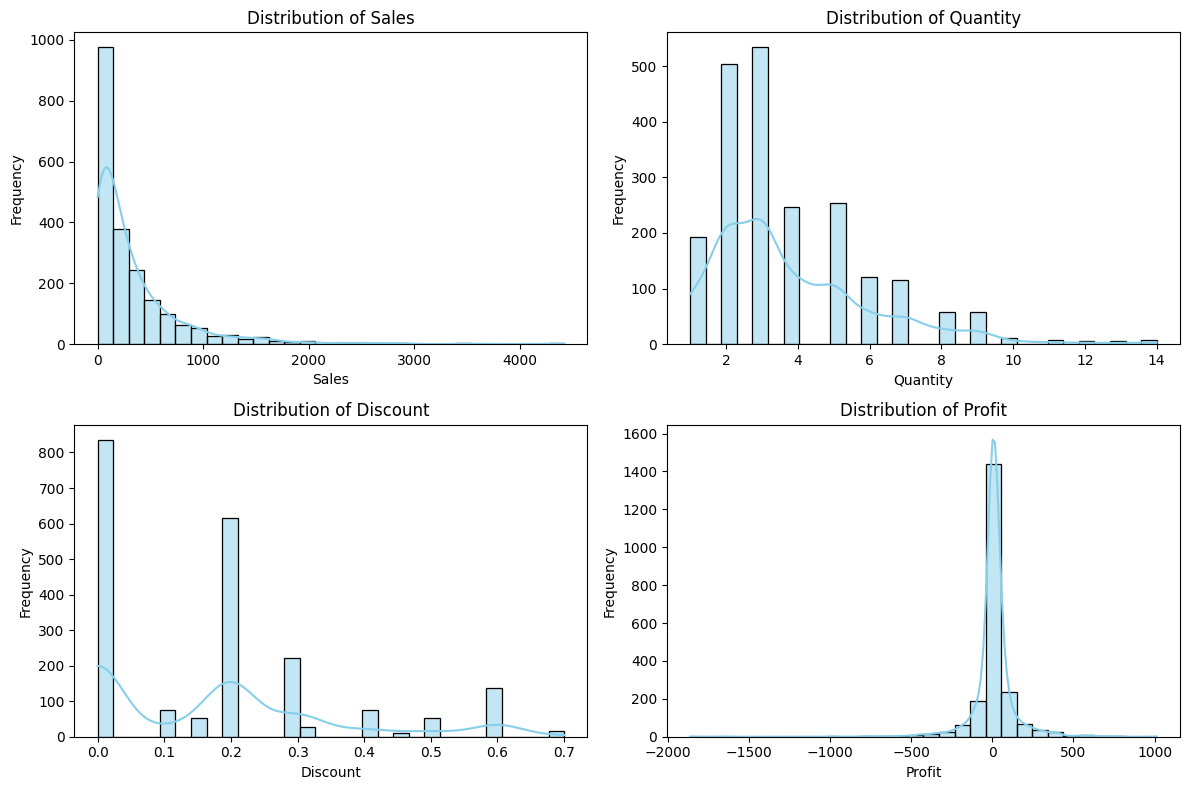

In [25]:
# Histogram for numerical features

num_features = ['Sales', 'Quantity', 'Discount','Profit']

# Set up the plotting area
plt.figure(figsize=(12, 8))

# Plot histograms for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# _____________Correlation Analysis_____________
Heatmap of Key Metrics Correlation
The following heatmap visualizes the correlation between four key business metrics: Sales, Quantity, Discount, and Profit. Correlation measures the strength and direction of relationships between these variables, helping us understand potential dependencies.

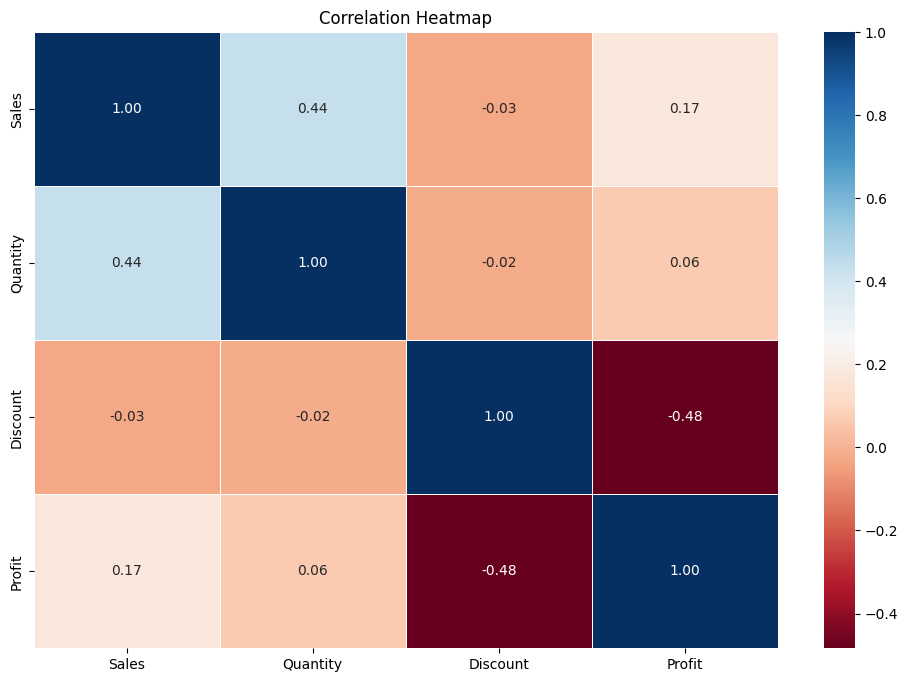

In [26]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Insights from Heatmap

Sales and Quantity (0.44 correlation)

There is a moderate positive relationship. As sales increase, the quantity sold tends to increase.
Discount and Profit (-0.48 correlation)

There is a moderate negative relationship. Higher discounts are linked to lower profits, indicating that large discounts can reduce profitability.
Sales and Profit (0.17 correlation)

There is a weak positive relationship. Increasing sales slightly improves profits, but the impact is limited, possibly due to discount effects.
Discount and Sales (-0.03 correlation)

There is almost no relationship, suggesting that discounts do not significantly influence sales volume.
Quantity and Profit (0.06 correlation)

There is a very weak positive relationship, indicating that selling more units doesn't strongly affect profitability.
Quantity and Discount (-0.02 correlation)

There is no significant relationship, meaning discounts do not notably influence the quantity sold.

# _________Outlier Detection Using IQR Method_________


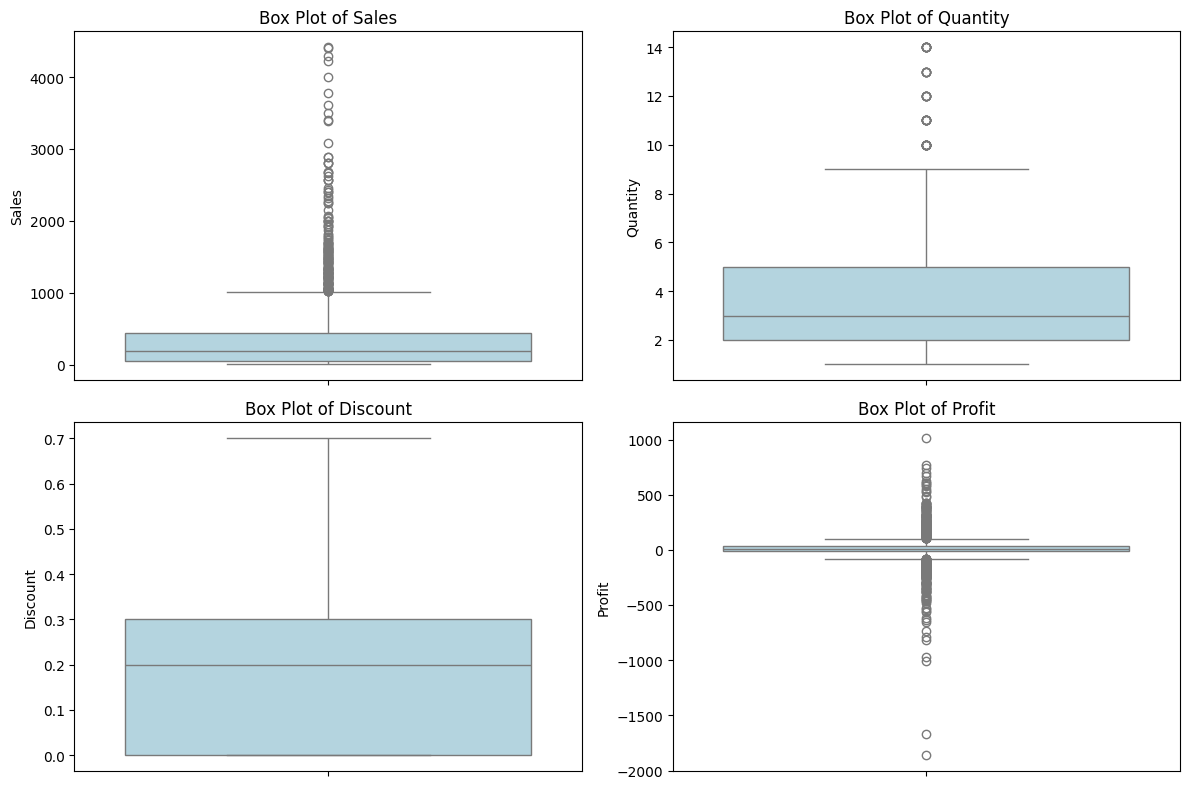

In [4]:
# List of numerical features
num_features = ['Sales', 'Quantity', 'Discount', 'Profit']

# Set up the plotting area
plt.figure(figsize=(12, 8))

# Plot simple box plots for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[feature], color='lightblue')
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

# _________Outliers winsorization__________

In [22]:
from scipy.stats.mstats import winsorize

for feature in num_features:
    df[feature] = winsorize(df[feature], limits=[0.05, 0.05])  # Cap 5% on both sides
    print(f"Outliers capped for {feature}")

Outliers capped for Sales
Outliers capped for Quantity
Outliers capped for Discount
Outliers capped for Profit


In [5]:
num_features = ['Sales', 'Quantity', 'Discount', 'Profit']

df_cleaned = df.copy()


for feature in num_features:
    Q1 = df_cleaned[feature].quantile(0.25)
    Q3 = df_cleaned[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[feature] >= lower_bound) & (df_cleaned[feature] <= upper_bound)]

print(f"Data shape before outlier removal: {df.shape}")
print(f"Data shape after outlier removal: {df_cleaned.shape}")

Data shape before outlier removal: (2121, 21)
Data shape after outlier removal: (1597, 21)


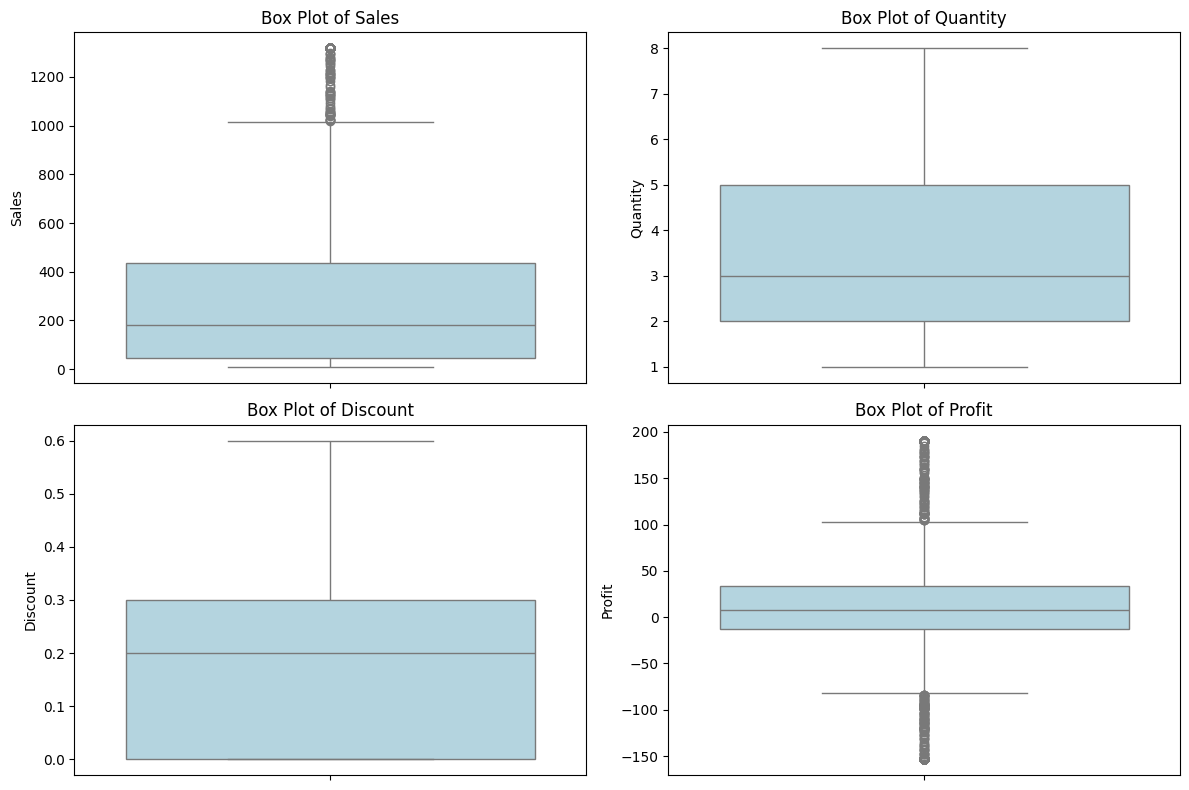

In [24]:
# List of numerical features
num_features = ['Sales', 'Quantity', 'Discount', 'Profit']

# Set up the plotting area
plt.figure(figsize=(12, 8))

# Plot simple box plots for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[feature], color='lightblue')
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

# ___Exploratory Data Analysis (EDA) on Categorical Features___

Ship Mode
Standard Class    1248
Second Class       427
First Class        327
Same Day           119
Name: count, dtype: int64


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_20704\1477392013.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='deep')  # Corrected 'palette'


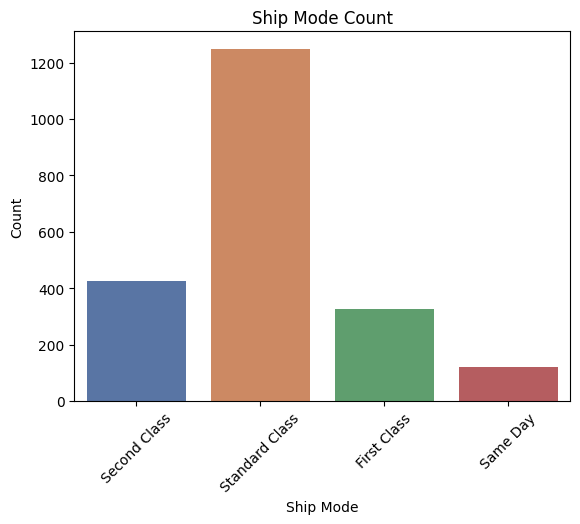

Segment
Consumer       1113
Corporate       646
Home Office     362
Name: count, dtype: int64


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_20704\1477392013.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='deep')  # Corrected 'palette'


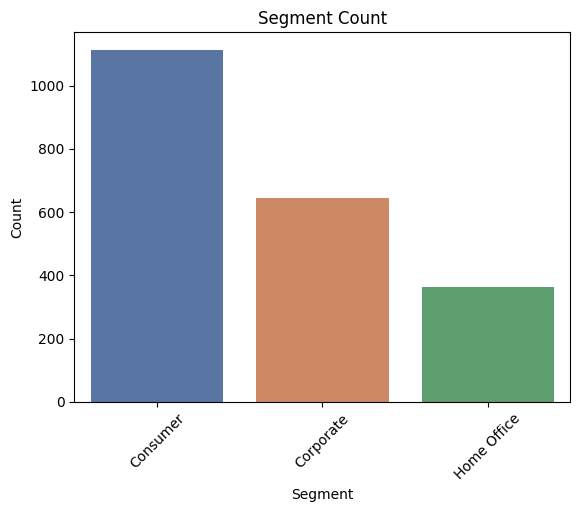

Region
West       707
East       601
Central    481
South      332
Name: count, dtype: int64


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_20704\1477392013.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='deep')  # Corrected 'palette'


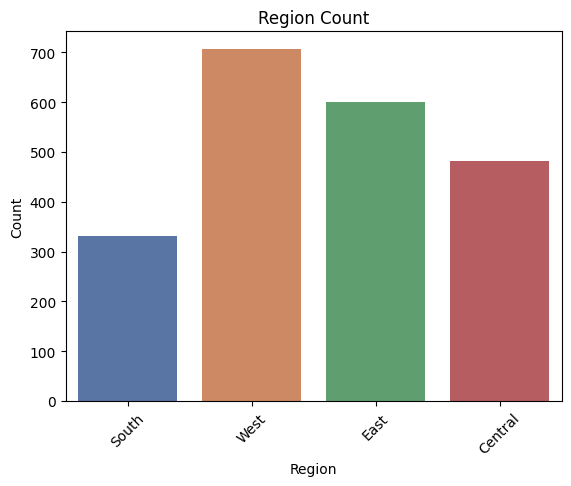

Sub-Category
Furnishings    957
Chairs         617
Tables         319
Bookcases      228
Name: count, dtype: int64


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_20704\1477392013.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette='deep')  # Corrected 'palette'


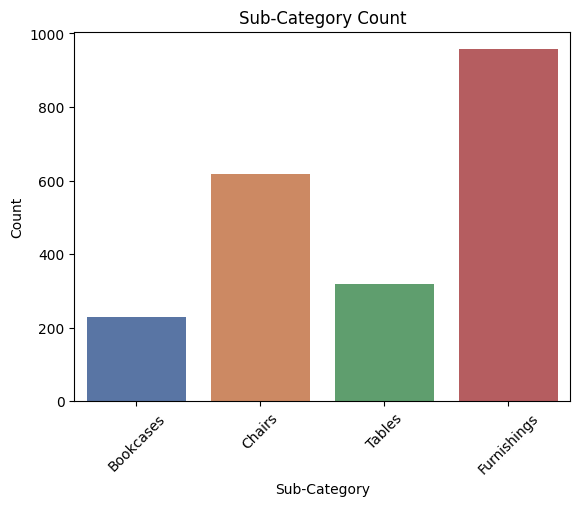

In [6]:
# Categorical features
categorical_features = ['Ship Mode', 'Segment', 'Region', 'Sub-Category']

for feature in categorical_features:
    print(df[feature].value_counts())
    sns.countplot(x=feature, data=df, palette='deep')  # Corrected 'palette'
    plt.title(f'{feature} Count')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# _______Visualizing Region Distribution_______

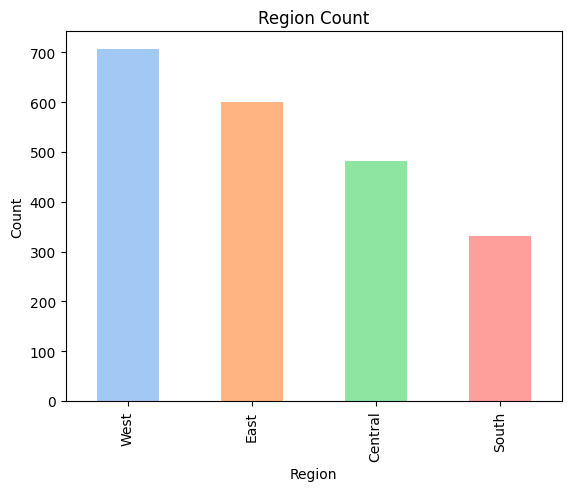

In [32]:
colors = sns.color_palette('pastel')

# Plot the bar chart with custom colors
df.Region.value_counts().plot(kind="bar", color=colors)

# Add titles and labels for clarity (optional)
plt.title("Region Count")
plt.xlabel("Region")
plt.ylabel("Count")

# Display the plot
plt.show()

# _____Visualizing Sub-Category Distribution with a Pie Chart_____

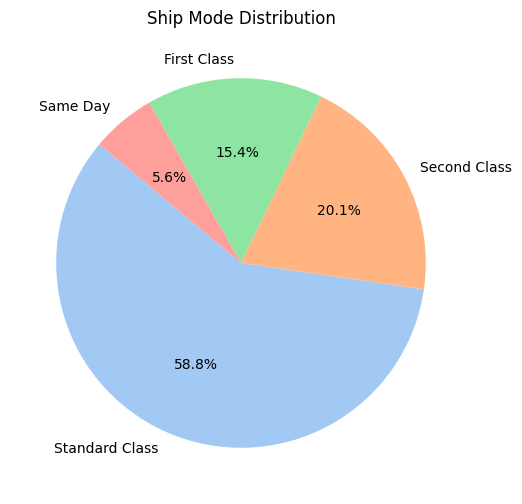

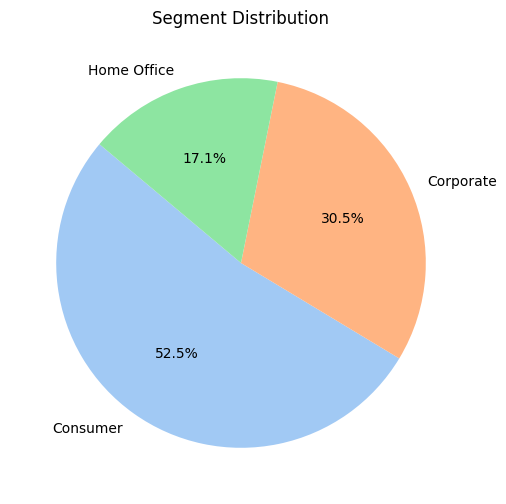

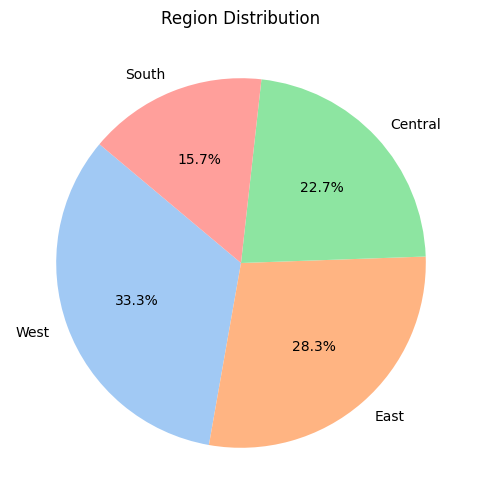

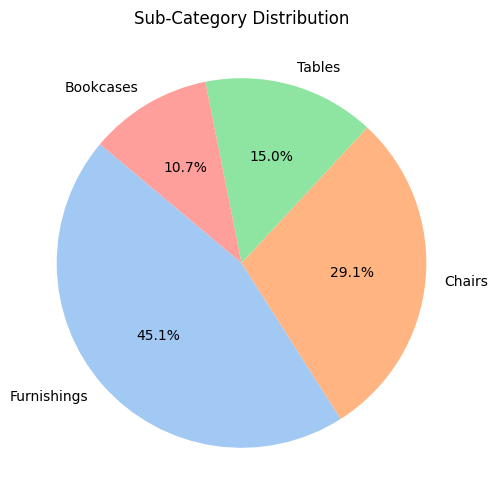

In [26]:
# Categorical features
categorical_features = ['Ship Mode', 'Segment', 'Region', 'Sub-Category']

for feature in categorical_features:
    # Get value counts
    counts = df[feature].value_counts()

    # Plot pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title(f'{feature} Distribution')

    plt.show()

# ______Sales Data Distribution_______

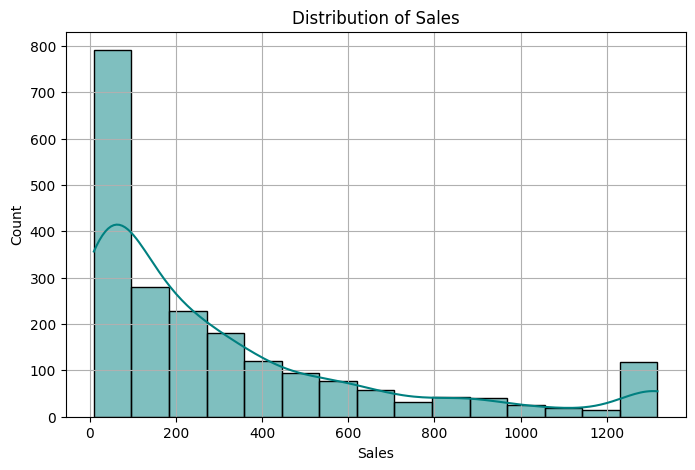

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=15, kde=True, color='teal')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# _______Region vs. Segment Distribution_________

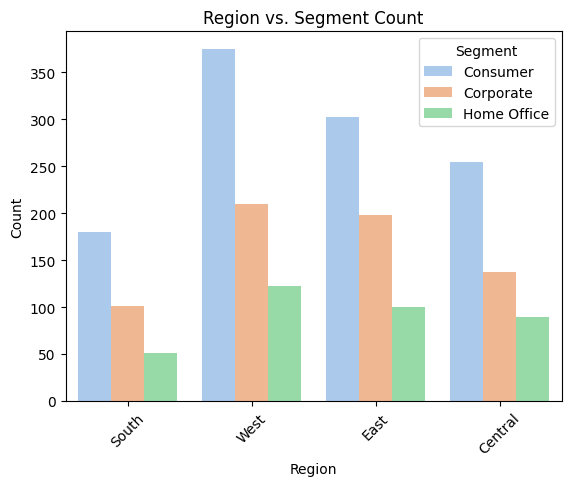

In [7]:
sns.countplot(x='Region', hue='Segment', data=df, palette='pastel')
plt.title("Region vs. Segment Count")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ______Pairplot Analysis of Sales Data by Region_______

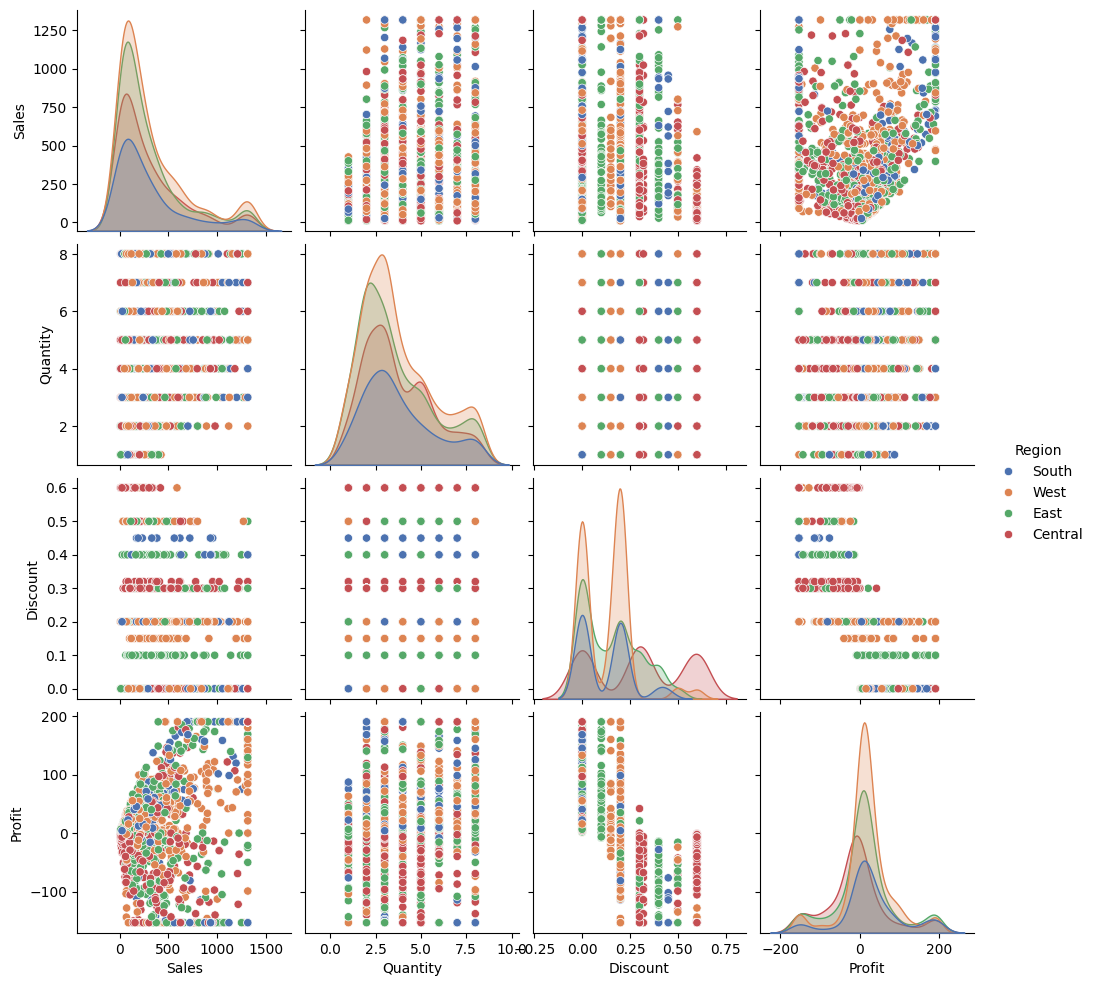

In [36]:
sns.pairplot(df, hue='Region', palette='deep', diag_kind='kde')
plt.show()

# ______Profit Distribution Across Segments_______

C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_20704\1437425483.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Segment', y='Profit', data=df, palette='dark')


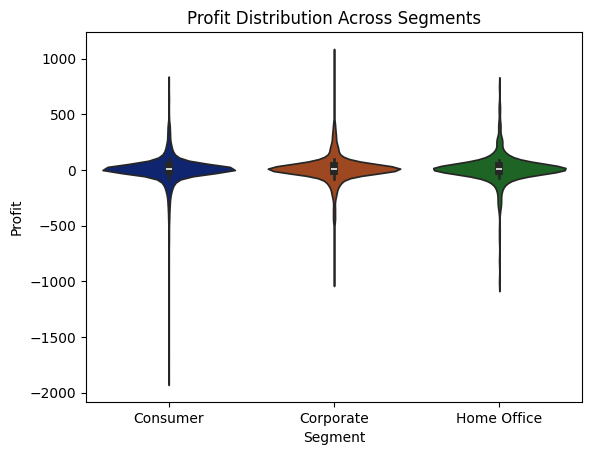

In [8]:
sns.violinplot(x='Segment', y='Profit', data=df, palette='dark')
plt.title("Profit Distribution Across Segments")
plt.show()

# _______Top 10 Products by Total Sales_______


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_12904\99675262.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.index, y=top_products.values, palette='coolwarm')


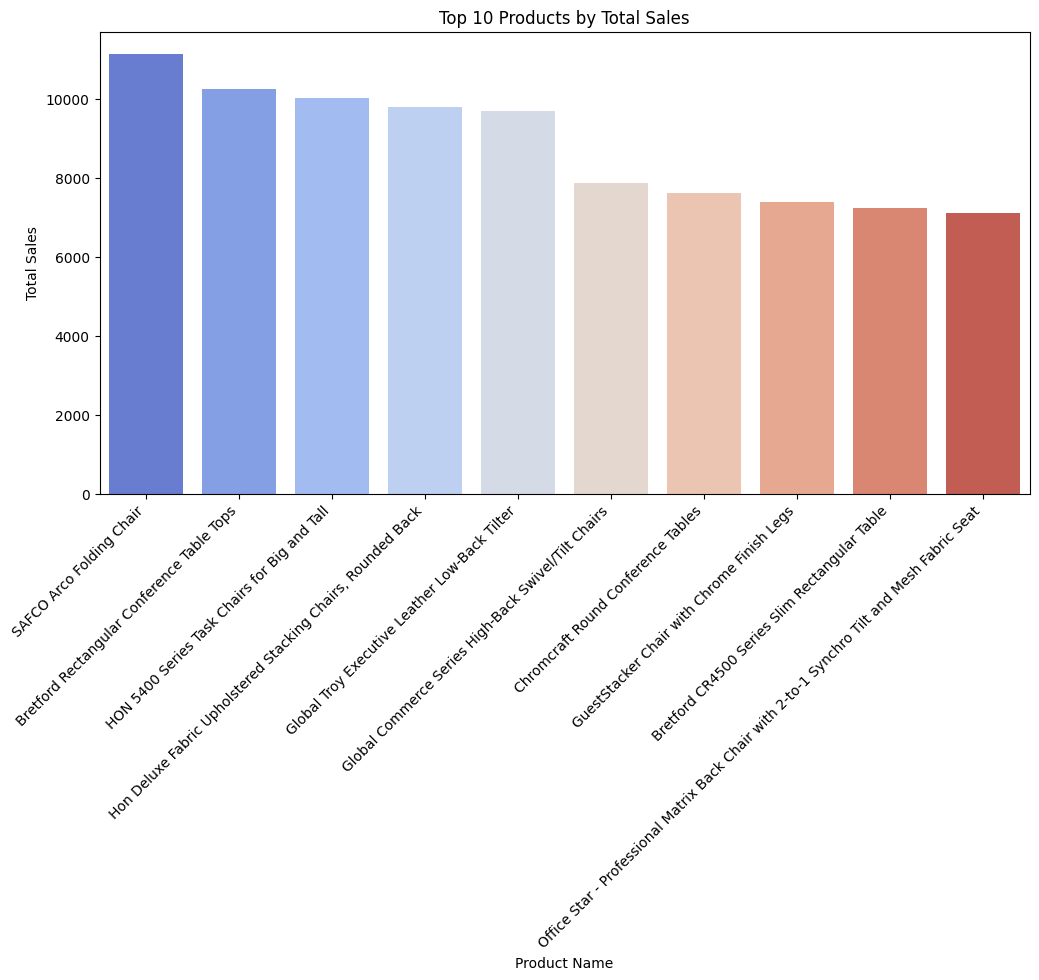

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort products by total sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.index, y=top_products.values, palette='coolwarm')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

# ________Total Sales by Sub-Category__________

C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_12904\4169505280.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sub-Category', y='Sales', data=df, palette='coolwarm', estimator=sum)


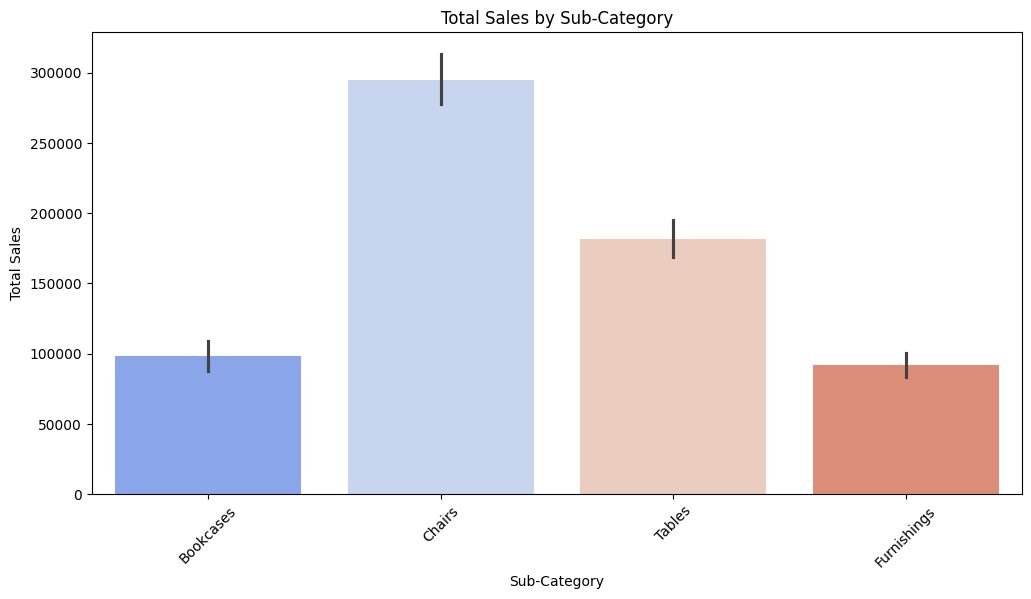

In [39]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Sub-Category', y='Sales', data=df, palette='coolwarm', estimator=sum)
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

# ______Sales vs Profit by Sub-Category_________

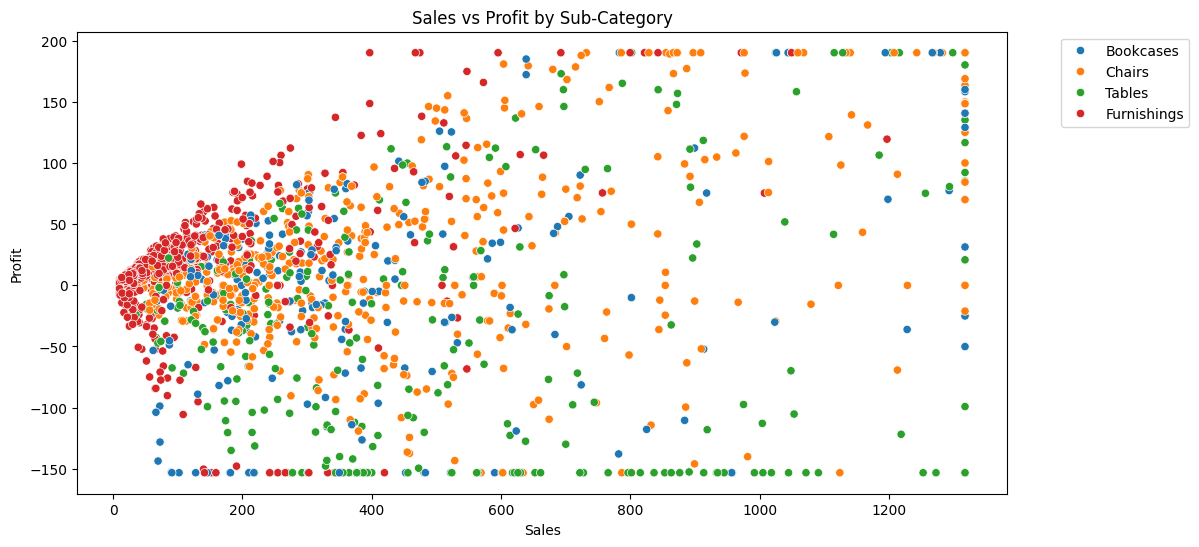

In [40]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Sub-Category', palette='tab10')
plt.title('Sales vs Profit by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Hypothesis testing
For all features affect on sales

In [9]:
region1 = "East"
region2 = "West"
region3 = "South"
region4 = "Central"


sales_region1 = df[df["Region"] == region1]["Sales"]
sales_region2 = df[df["Region"] == region2]["Sales"]
sales_region3 = df[df["Region"] == region3]["Sales"]
sales_region4 = df[df["Region"] == region4]["Sales"]

f_stat, p_value = stats.f_oneway(sales_region1, sales_region2, sales_region3, sales_region4)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in sales between the regions.")
else:
    print("Fail to reject the null hypothesis: No significant difference in sales between the regions.")


F-statistic: 0.1202
P-value: 0.9482
Fail to reject the null hypothesis: No significant difference in sales between the regions.


In [10]:
corr, p_value = stats.pearsonr(df["Discount"], df["Sales"])


print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant correlation between discount and sales.")
else:
    print("Fail to reject the null hypothesis: No significant correlation between discount and sales.")

Pearson Correlation Coefficient: -0.0286
P-value: 0.1883
Fail to reject the null hypothesis: No significant correlation between discount and sales.


In [11]:
consumer_sales = df[df["Segment"] == "Consumer"]["Sales"]
corporate_sales = df[df["Segment"] == "Corporate"]["Sales"]
home_office_sales = df[df["Segment"] == "Home Office"]["Sales"]

f_stat, p_value = stats.f_oneway(consumer_sales, corporate_sales, home_office_sales)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis: At least one segment has significantly different sales.")
else:
    print("Fail to reject the null hypothesis: No significant difference in sales among segments.")

F-statistic: 0.1539
P-value: 0.8574
Fail to reject the null hypothesis: No significant difference in sales among segments.


In [12]:
cities = df['City'].unique()


sales_data = [df[df["City"] == city]["Sales"] for city in cities]

f_stat, p_value = stats.f_oneway(*sales_data)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in sales between cities.")
else:
    print("Fail to reject the null hypothesis: No significant difference in sales between cities.")

F-statistic: 0.9434
P-value: 0.7574
Fail to reject the null hypothesis: No significant difference in sales between cities.


In [13]:
cities = df['City'].unique()


sales_data = [df[df["City"] == city]["Sales"] for city in cities]

f_stat, p_value = stats.f_oneway(*sales_data)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in sales between cities.")
else:
    print("Fail to reject the null hypothesis: No significant difference in sales between cities.")

F-statistic: 0.9434
P-value: 0.7574
Fail to reject the null hypothesis: No significant difference in sales between cities.


In [14]:
ship_mode1 = "Standard Class"
ship_mode2 = "Second Class"
ship_mode3 = "First Class"
ship_mode4 = "Same Day"

sales_mode1 = df[df["Ship Mode"] == ship_mode1]["Sales"]
sales_mode2 = df[df["Ship Mode"] == ship_mode2]["Sales"]
sales_mode3 = df[df["Ship Mode"] == ship_mode3]["Sales"]
sales_mode4 = df[df["Ship Mode"] == ship_mode4]["Sales"]

t_stat, p_value = stats.ttest_ind(sales_mode1, sales_mode2, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Reject the null hypothesis: There is a significant difference in sales between {ship_mode1} and {ship_mode2}.")
else:
    print(f"Fail to reject the null hypothesis: No significant difference in sales between {ship_mode1} and {ship_mode2}.")

T-statistic: -0.5359
P-value: 0.5922
Fail to reject the null hypothesis: No significant difference in sales between Standard Class and Second Class.


In [15]:
states = df['State'].unique()


sales_data = [df[df["State"] == state]["Sales"] for state in states]

f_stat, p_value = stats.f_oneway(*sales_data)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in sales between states.")
else:
    print("Fail to reject the null hypothesis: No significant difference in sales between states.")

F-statistic: 2.1890
P-value: 0.0000
Reject the null hypothesis: There is a significant difference in sales between states.


# Modeling

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


y = df['Sales']

X = df.drop(['Sales', 'Product Name'], axis=1)

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)
score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Linear Regression Performance:")
print("R^2 score:", f"{score:.2%}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Linear Regression Performance:
R^2 score: -1061161.65%
MAE: 42424.95
MSE: 3251919736.02
RMSE: 57025.61


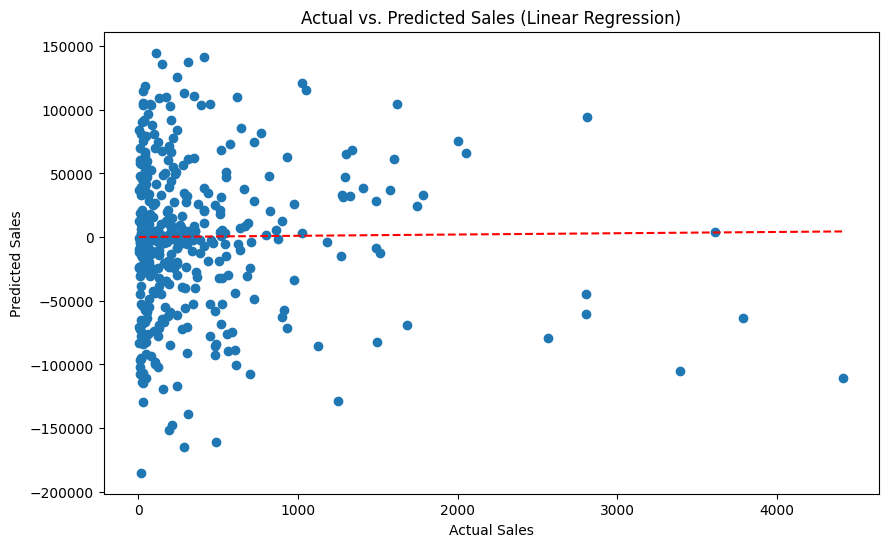

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales (Linear Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Add a diagonal line for reference
plt.show()

In [29]:
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

print("Random Forest Regression Performance:")
print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Random Forest Regression Performance:
R² Score: 81.79%
MAE: 80.06
MSE: 23523.21
RMSE: 153.37


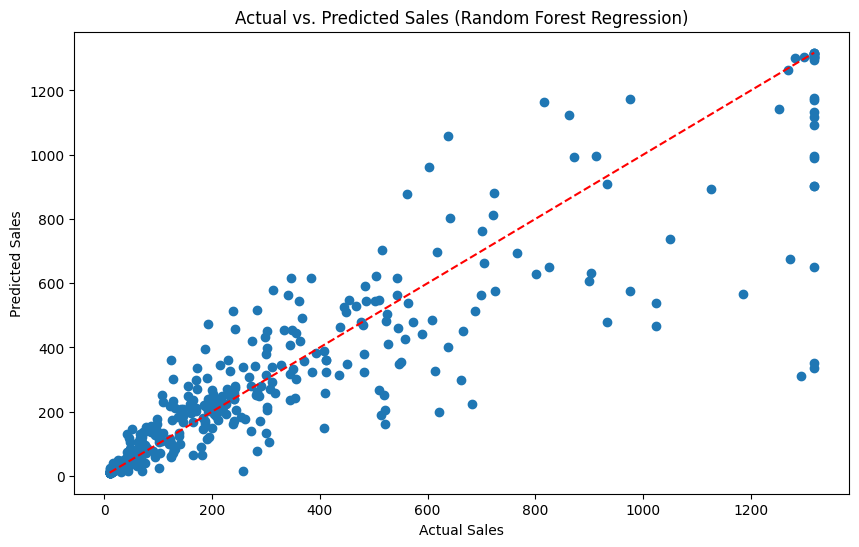

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales (Random Forest Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()


In [31]:
from sklearn.tree import DecisionTreeRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)


y_pred = dt_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


print(" Decision Tree Regression Performance:")
print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


 Decision Tree Regression Performance:
R² Score: 76.41%
MAE: 102.89
MSE: 30471.27
RMSE: 174.56


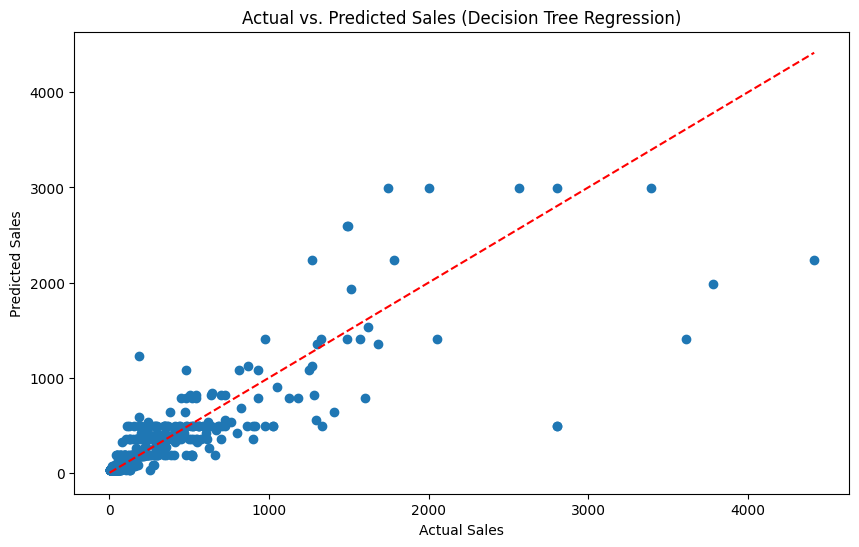

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales (Decision Tree Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()


In [17]:
from sklearn.svm import SVR

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)


svr_model.fit(X_train, y_train)


y_pred = svr_model.predict(X_test)


r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


print("SVR Performance:")
print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

SVR Performance:
R² Score: -8.08%
MAE: 289.31
MSE: 331177.94
RMSE: 575.48


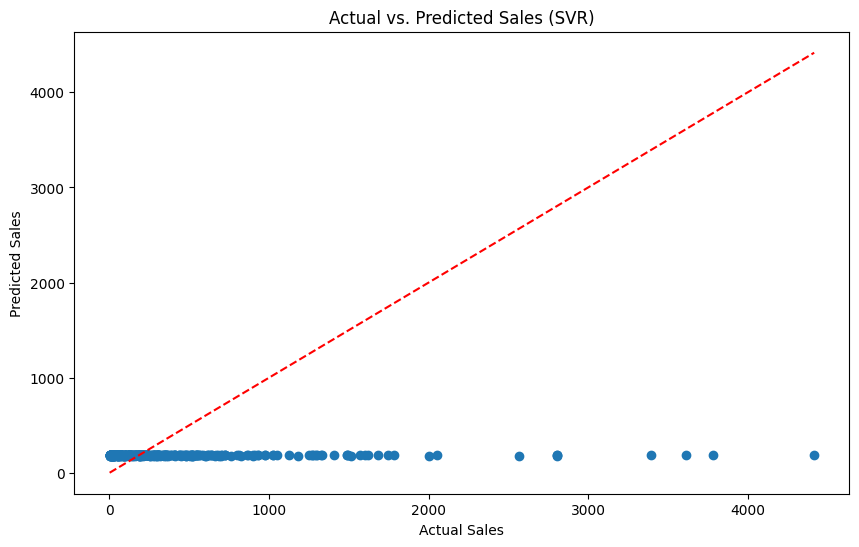

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales (SVR)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

r2 = r2_score(y_test, y_pred_gbr)
mae = mean_absolute_error(y_test, y_pred_gbr)
mse = mean_squared_error(y_test, y_pred_gbr)
rmse = np.sqrt(mse)

print("Gradient Boosting Regression Performance:")
print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Gradient Boosting Regression Performance:
R² Score: 84.02%
MAE: 88.60
MSE: 20634.41
RMSE: 143.65


In [33]:
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

print("XGBoost Regression Performance:")
print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

XGBoost Regression Performance:
R² Score: 85.16%
MAE: 75.49
MSE: 19163.30
RMSE: 138.43


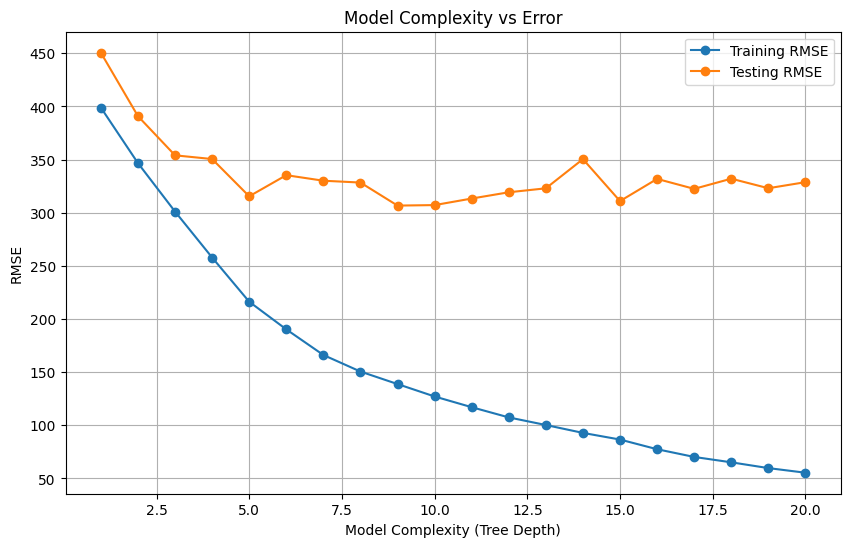

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


train_errors = []
test_errors = []
depths = range(1, 21)

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)


plt.figure(figsize=(10,6))
plt.plot(depths, train_errors, label="Training RMSE", marker='o')
plt.plot(depths, test_errors, label="Testing RMSE", marker='o')
plt.xlabel("Model Complexity (Tree Depth)")
plt.ylabel("RMSE")
plt.title("Model Complexity vs Error")
plt.legend()
plt.grid(True)
plt.show()

# Regularization

In [25]:
from sklearn.linear_model import Ridge

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=0.001)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

C:\Users\VINAYAK\anaconda3\envs\vinenv\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


MSE: 499986.9687834672
R² Score: -0.6317038549568781


In [26]:
from sklearn.ensemble import VotingRegressor
models=[('gbr', gbr_model),('rfr', rf_model),('xgb', xgb_model)]

voting_reg = VotingRegressor(estimators=models)

voting_reg.fit(X_train, y_train)

y_pred_voting = voting_reg.predict(X_test)

print("Voting Regressor Performance:")
print(f"R² Score: {r2_score(y_test, y_pred_voting):.2%}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_voting)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_voting):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_voting):.2f}")

Voting Regressor Performance:
R² Score: 77.38%
RMSE: 263.27
MAE: 109.32
MSE: 69311.13


In [28]:
from sklearn.model_selection import learning_curve
def plot_learning_curve(clf, X, Y, title="Learning Curve"):
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X, Y, cv=10, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), verbose=0
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid(True)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="b", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="r", label="Test score")

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="r")

    plt.legend(loc="best")
    plt.show()

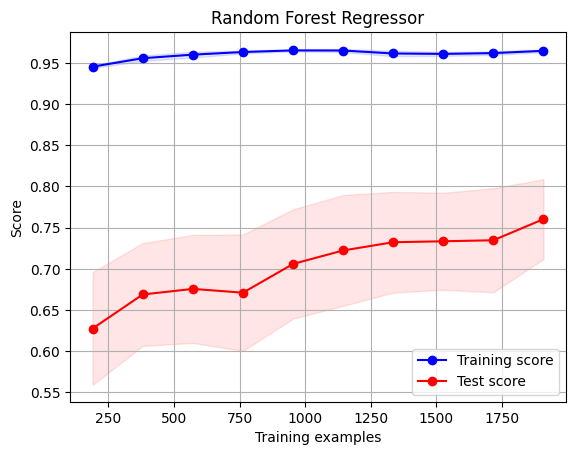

In [29]:
plot_learning_curve(rf_model, X,y, "Random Forest Regressor")

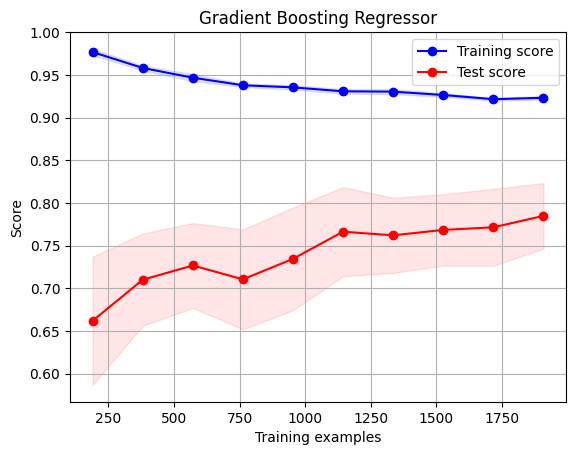

In [30]:
plot_learning_curve(gbr_model, X,y, "Gradient Boosting Regressor")

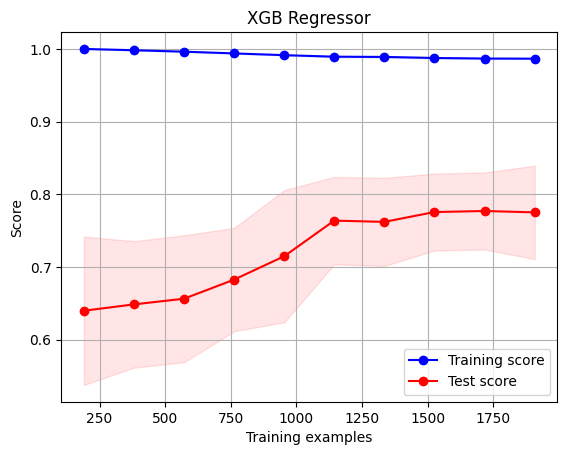

In [31]:
plot_learning_curve(xgb_model, X,y, "XGB Regressor")

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Assuming X and y are already defined from the previous code

# Define the model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),  # Add dropout for regularization
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error: {mae}")

# Make predictions
y_pred = model.predict(X_test)

C:\Users\VINAYAK\anaconda3\envs\vinenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 668426.7500 - mae: 544.0698 - val_loss: 216855.2031 - val_mae: 259.5405
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 306021.9375 - mae: 350.6173 - val_loss: 206321.1719 - val_mae: 284.6804
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 284213.0938 - mae: 335.0260 - val_loss: 206686.5625 - val_mae: 277.3960
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 280474.2500 - mae: 328.7964 - val_loss: 205720.8906 - val_mae: 295.0255
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 275004.8125 - mae: 336.4808 - val_loss: 206223.4531 - val_mae: 282.5135
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 276528.6562 - mae: 327.1288 - val_loss: 204725.5000 - val_mae: 288.4531
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 275792.1562 - mae: 332.1589 - val_loss: 206290.1875 - val_mae: 286.7028
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 268457.6875 - mae: 327.6

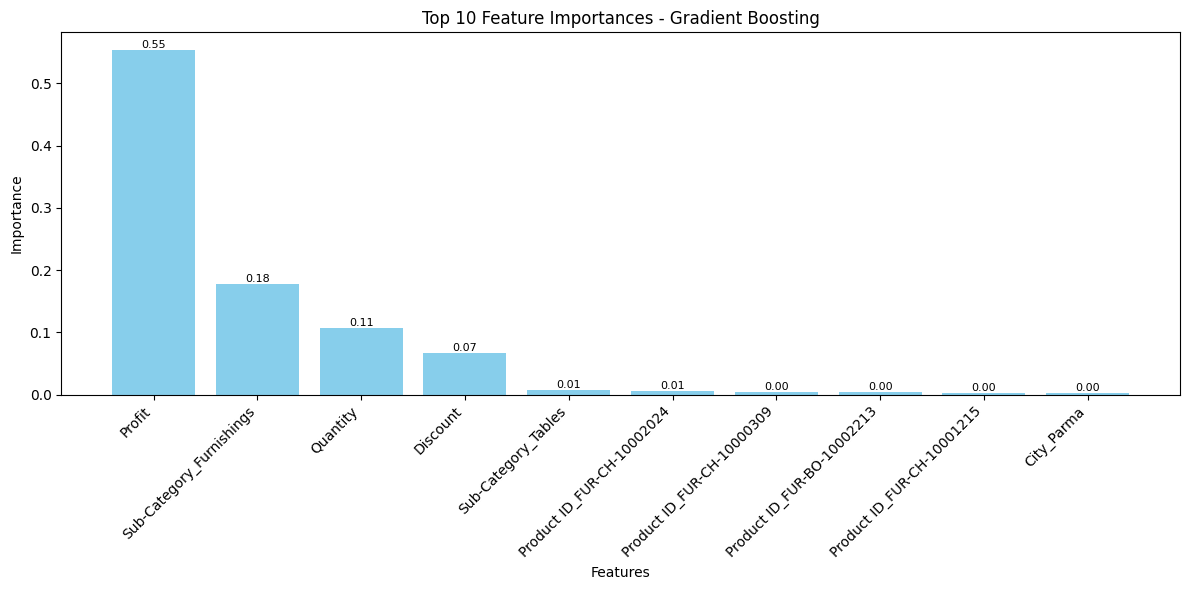

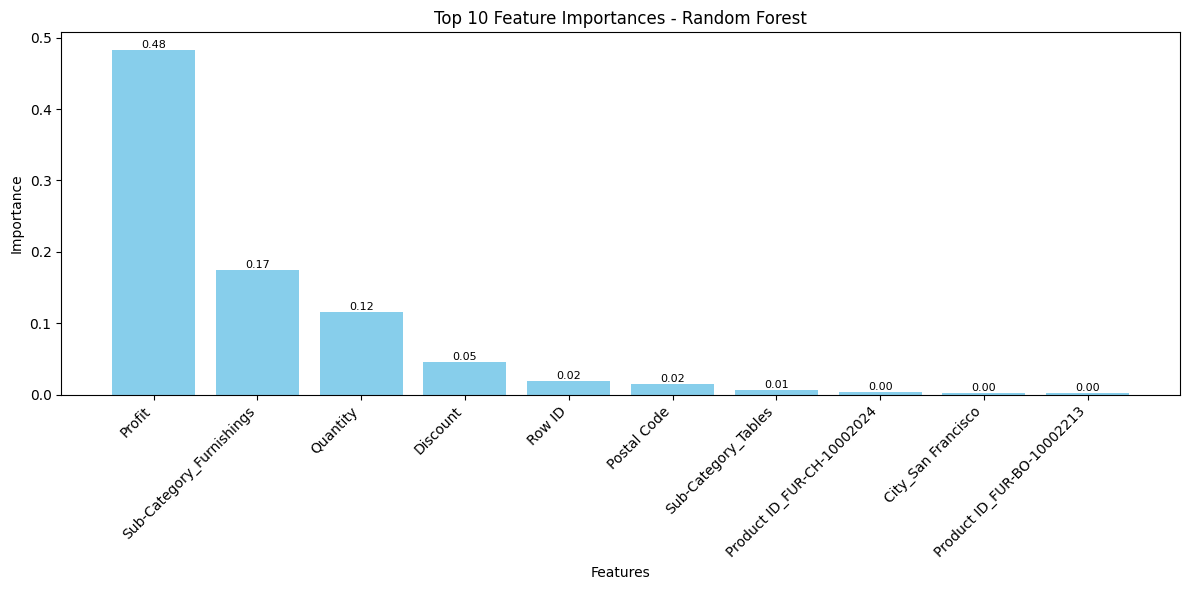

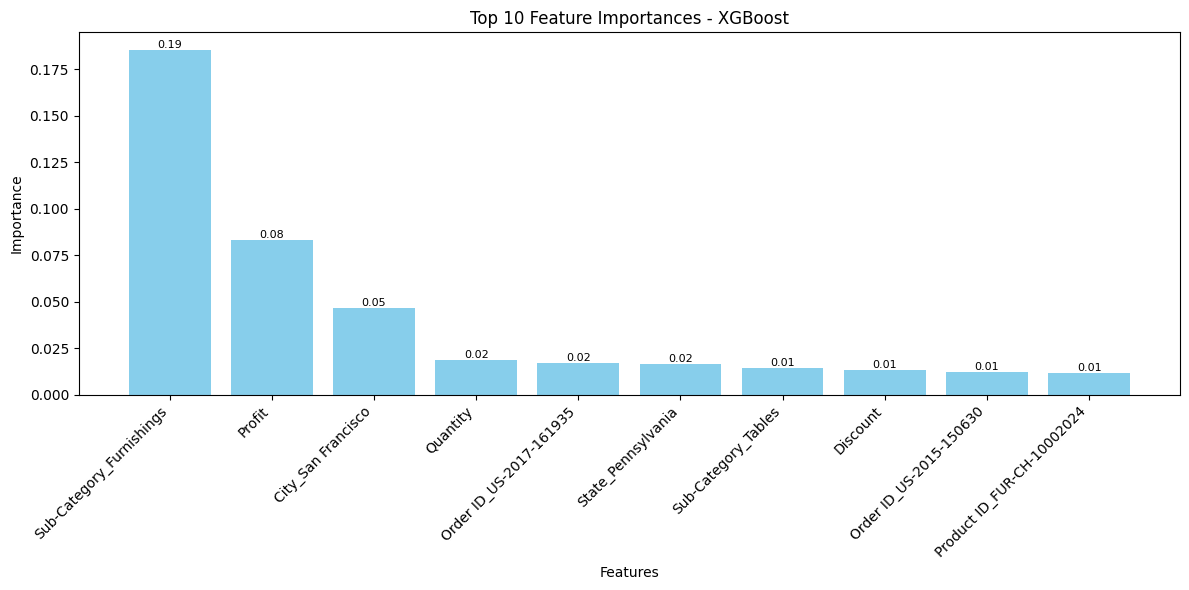

In [34]:
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)

models = [('Gradient Boosting', gbr_model),
          ('Random Forest', rf_model),
           ('XGBoost', xgb_model)
         ]

# Loop through each model and plot feature importances
for model_name, model in models:
    # Get feature importances
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    top_n = 10
    top_indices = indices[:top_n]
    top_features = X.columns[top_indices]
    top_importances = importances[top_indices]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.title(f"Top {top_n} Feature Importances - {model_name}")
    bars = plt.bar(range(top_n), top_importances, color='skyblue')
    plt.xticks(range(top_n), top_features, rotation=45, ha='right')
    plt.xlabel("Features")
    plt.ylabel("Importance")

    for bar, imp in zip(bars, top_importances):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{imp:.2f}",
                 ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter
df['Weekday'] = df['Order Date'].dt.dayofweek

                         Feature    Importance
4                         Profit  4.831577e-01
5827    Sub-Category_Furnishings  1.749170e-01
2                       Quantity  1.161573e-01
3                       Discount  4.554819e-02
0                         Row ID  1.879258e-02
...                          ...           ...
5733  Product ID_FUR-FU-10003981  0.000000e+00
1119     Order ID_CA-2017-118773 -6.511964e-25
2699         Ship Date_1/31/2014 -1.302393e-24
1771        Order Date_1/11/2014 -1.903097e-24
4016        Customer ID_LB-16735 -5.234512e-24

[5829 rows x 2 columns]


C:\Users\VINAYAK\anaconda3\envs\vinenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 138 (\x8a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\VINAYAK\anaconda3\envs\vinenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 154 (\x9a) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


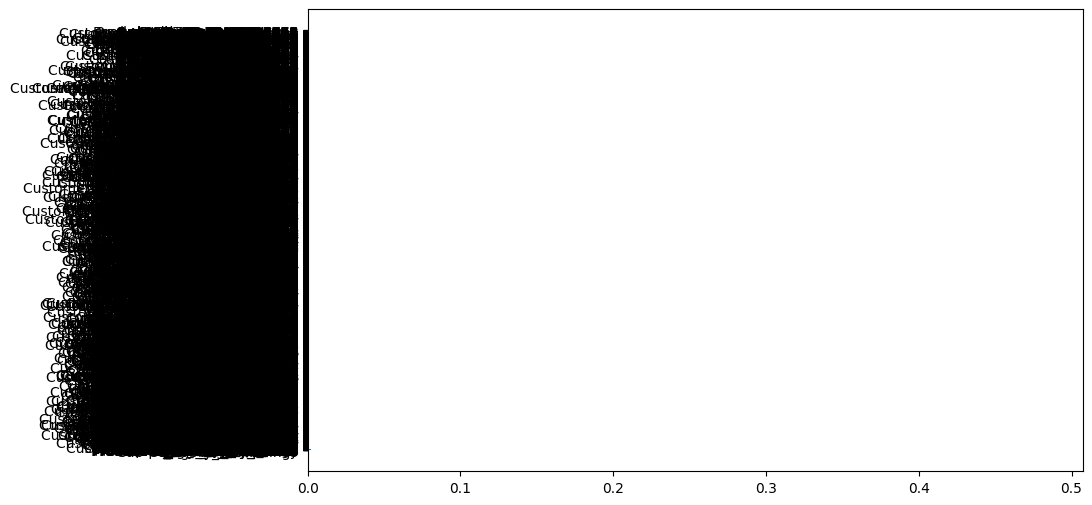

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.show()

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators':[100,200,300,500],
    'max_depth':[5,10,15,20,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train,y_train)

best_rf = random_search.best_estimator_

print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}


In [37]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

pred = best_rf.predict(X_test)

print("R2 :",r2_score(y_test,pred))
print("MAE :",mean_absolute_error(y_test,pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

R2 : 0.8190488153080772
MAE : 85.65842227097282
RMSE : 152.8679217294707


In [38]:
import joblib

joblib.dump(
    best_rf,
    'sales_forecasting_model.pkl'
)

['sales_forecasting_model.pkl']

In [39]:
joblib.dump(
    encoder,
    'encoder.pkl'
)

NameError: name 'encoder' is not defined

In [40]:
app.py

NameError: name 'app' is not defined

In [42]:
import streamlit as st
import joblib
import pandas as pd

model = joblib.load(
    'sales_forecasting_model.pkl'
)

st.title("Sales Forecasting System")

quantity = st.number_input(
    "Quantity",
    min_value=1
)

discount = st.number_input(
    "Discount",
    min_value=0.0,
    max_value=1.0
)

profit = st.number_input(
    "Profit"
)

if st.button("Predict Sales"):

    data = pd.DataFrame({
        'Quantity':[quantity],
        'Discount':[discount],
        'Profit':[profit]
    })

    prediction = model.predict(data)

    st.success(
        f"Predicted Sales : ₹{prediction[0]:.2f}"
    )

2026-06-22 00:17:03.216 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 00:17:03.495 
  command:

    streamlit run C:\Users\VINAYAK\anaconda3\envs\vinenv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-22 00:17:03.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 00:17:03.497 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 00:17:03.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 00:17:03.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 00:17:03.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 00:17:03.500 Thread 'M

In [10]:
import joblib

joblib.dump(
    X.columns.tolist(),
    'feature_columns.pkl'
)

['feature_columns.pkl']

In [11]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [12]:
feature_columns = joblib.load("feature_columns.pkl")

print(type(feature_columns))
print(feature_columns[:5])

<class 'list'>
['Row ID', 'Postal Code', 'Quantity', 'Discount', 'Profit']
